# Conditional Graph Task


In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [4]:
class AgentState(TypedDict):
    operation1:str
    operation2:str
    number1:int
    number2:int
    number3:int
    number4:int
    final1:int
    final2:int

In [5]:
def add_node(state:AgentState)->AgentState:
    """
    This node adds the values of number 1 and number 2
     """

    state['final1'] = state['number1'] + state['number2']

    return state

def add_node2(state:AgentState)->AgentState:
    """
    This node adds the values of number 3 and number 4
     """

    state['final2'] = state['number3'] + state['number4']

    return state

In [8]:
def substract_node(state:AgentState)->AgentState:
    """
    This node substract the values of number 1 and number 2
     """

    state['final1'] = state['number1'] - state['number2']

    return state

def substract_node2(state:AgentState)->AgentState:
    """
    This node substract the values of number 3 and number 4
     """

    state['final2'] = state['number3'] - state['number4']

    return state

In [18]:
def router_node(state:AgentState)->str:

    """
    This node decides which node to take next
    """

    if state['operation1'] == "+":
        return "addition_node"
    elif state["operation1"] == "-":
        return "substraction_node"
    else:
        return END

def router_node2(state:AgentState)->str:

    """
    This node decides which node to take next
    """

    if state['operation2'] == "+":
        return "addition_node"
    elif state["operation2"] == "-":
        return "substraction_node"
    else:
        return END


In [19]:
graph = StateGraph(AgentState)

graph.add_node("add1",add_node )
graph.add_node("add2",add_node2 )
graph.add_node("sub1",substract_node )
graph.add_node("sub2",substract_node2 )

graph.add_node("router", lambda state:state)
graph.add_node("router2", lambda state:state)

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    router_node,
    {
        "addition_node": "add1",
        "substraction_node": "sub1"
    }
)

graph.add_edge("add1", "router2")
graph.add_edge("sub1", "router2")

graph.add_conditional_edges(
    "router2",
    router_node2,
    {
        "addition_node":"add2",
        "substraction_node": "sub2"
    }
)

graph.add_edge("add2", END)
graph.add_edge("sub2", END)


app = graph.compile()

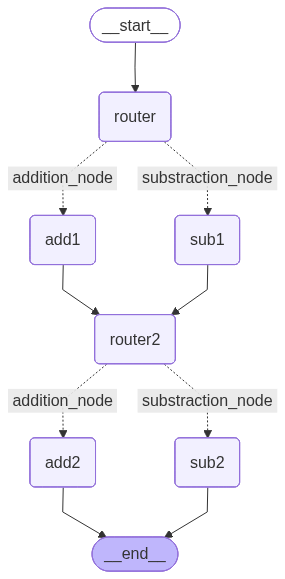

In [20]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
result = app.invoke({
    "operation1":"+",
    "operation2":"-",
    "number1":3,
    "number2":2,
    "number3":5,
    "number4":1
})

result

{'operation1': '+',
 'operation2': '-',
 'number1': 3,
 'number2': 2,
 'number3': 5,
 'number4': 1,
 'final1': 5,
 'final2': 4}